<a href="https://colab.research.google.com/github/e23383/Statistical-Learning-e23383/blob/main/Assignment%207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analytical Derivation of Kalman Filter

## 1. Distribution of Prior State

Given:
- $x_{k-1}^+ \sim \mathcal{N}(m_{k-1}, P_{k-1})$
- $w_{k-1} \sim \mathcal{N}(0, \Sigma_p)$ (process noise, independent of $x_{k-1}^+$)

The state prediction equation is:
$$x_k^- = A_{k-1} x_{k-1}^+ + G_{k-1} w_{k-1}$$

### Mean of $x_k^-$:
$$\mathbb{E}[x_k^-] = A_{k-1} \mathbb{E}[x_{k-1}^+] + G_{k-1} \mathbb{E}[w_{k-1}] = A_{k-1} m_{k-1} + 0 = m_k^-$$

### Covariance of $x_k^-$:
$$\text{Var}(x_k^-) = A_{k-1} \text{Var}(x_{k-1}^+) A_{k-1}^T + G_{k-1} \text{Var}(w_{k-1}) G_{k-1}^T$$
$$\text{Var}(x_k^-) = A_{k-1} P_{k-1} A_{k-1}^T + G_{k-1} \Sigma_p G_{k-1}^T = P_k^-$$

Since $x_k^-$ is a linear combination of independent Gaussian random variables, it is Gaussian:
$$x_k^- \sim \mathcal{N}(m_k^-, P_k^-)$$

---

## 2. Distribution of Predicted Measurement

The measurement prediction is:
$$y_k^- = H_k x_k^- + z_k$$

Given $x_k^- \sim \mathcal{N}(m_k^-, P_k^-)$ and $z_k \sim \mathcal{N}(0, \Sigma_m)$ (measurement noise, independent of $x_k^-$):

### Mean of $y_k^-$:
$$\mathbb{E}[y_k^-] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^- + 0 = H_k m_k^-$$

### Covariance of $y_k^-$:
$$\text{Var}(y_k^-) = H_k \text{Var}(x_k^-) H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$

Therefore:
$$y_k^- \sim \mathcal{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$$

---

## 3. Joint Distribution of State and Measurement

The joint distribution of $x_k^-$ and $y_k^-$ can be obtained from the linear transformation:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} = \begin{bmatrix} I \\ H_k \end{bmatrix} x_k^- + \begin{bmatrix} 0 \\ z_k \end{bmatrix}$$

### Mean:
$$\mathbb{E}\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} = \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y_k^-] \end{bmatrix} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$$

### Covariance:
$$\text{Cov}\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} = \begin{bmatrix} \text{Var}(x_k^-) & \text{Cov}(x_k^-, y_k^-) \\ \text{Cov}(y_k^-, x_k^-) & \text{Var}(y_k^-) \end{bmatrix}$$

The cross-covariance:
$$\text{Cov}(x_k^-, y_k^-) = \text{Cov}(x_k^-, H_k x_k^- + z_k) = \text{Var}(x_k^-) H_k^T = P_k^- H_k^T$$

Thus:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right)$$

---

## 4. Posterior Distribution (Updated State)

The posterior distribution is the conditional distribution:
$$x_k^+ = (x_k^- | y_k^- = y_k^{0,\text{obs}})$$

Using the conditional Gaussian property, for:
$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right)$$

The conditional distribution is:
$$X | Y = y \sim \mathcal{N}(\mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y - \mu_Y), \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX})$$

### Applying this to our variables:
- $X = x_k^-$, $Y = y_k^-$
- $\mu_X = m_k^-$, $\mu_Y = H_k m_k^-$
- $\Sigma_{XX} = P_k^-$, $\Sigma_{XY} = P_k^- H_k^T$, $\Sigma_{YX} = H_k P_k^-$, $\Sigma_{YY} = H_k P_k^- H_k^T + \Sigma_m$

### Kalman Gain:
$$K_k = \Sigma_{XY} \Sigma_{YY}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

### Updated Mean:
$$m_k = m_k^- + K_k (y_k^{0,\text{obs}} - H_k m_k^-)$$

### Updated Covariance:
$$P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k) P_k^-$$

Therefore:
$$x_k^+ \sim \mathcal{N}(m_k, P_k)$$

---

## 5. Conditional Expectation and Variance

From the previous derivation, we have:
$$\mathbb{E}[x_k^- | y_k^- = y_k^{0,\text{obs}}] = m_k = m_k^- + K_k (y_k^{0,\text{obs}} - H_k m_k^-)$$

And:
$$\text{Var}(x_k^- | y_k^- = y_k^{0,\text{obs}}) = P_k = (I - K_k H_k) P_k^-$$

Where:
$$K_k = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

**Note:** The conditional expectation $\mathbb{E}[x_k^- | y_k^- = y_k^{0,\text{obs}}]$ is the minimum mean square error (MMSE) estimate of the state given the measurement, and the conditional variance $P_k$ represents the uncertainty in this estimate.

---

## Summary of Kalman Filter Equations

**Prediction Step:**
$$m_k^- = A_{k-1} m_{k-1}$$
$$P_k^- = A_{k-1} P_{k-1} A_{k-1}^T + G_{k-1} \Sigma_p G_{k-1}^T$$

**Update Step:**
$$K_k = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$
$$m_k = m_k^- + K_k (y_k^{0,\text{obs}} - H_k m_k^-)$$
$$P_k = (I - K_k H_k) P_k^-$$

These equations constitute the linear Kalman filter for state estimation.

# 1-D Kalman Filter Example

## 1. Prediction Step (Prior Distribution)

For the scalar system:
$$x_k^- = a x_{k-1}^+ + w_{k-1}, \quad w_{k-1} \sim \mathcal{N}(0, q)$$

### Mean:
$$\mathbb{E}[x_k^-] = a \mathbb{E}[x_{k-1}^+] + \mathbb{E}[w_{k-1}] = a m_{k-1} + 0 = a m_{k-1}$$

### Variance:
$$\text{Var}(x_k^-) = a^2 \text{Var}(x_{k-1}^+) + \text{Var}(w_{k-1}) = a^2 P_{k-1} + q$$

Therefore:
$$m_k^- = a m_{k-1}, \quad P_k^- = a^2 P_{k-1} + q$$

---

## 2. Update Step (Posterior Distribution)

For the measurement equation:
$$y_k^- = h x_k^- + z_k, \quad z_k \sim \mathcal{N}(0, r)$$

### Innovation (Residual):
$$v_k = y_k^{obs} - h m_k^-$$

### Innovation Variance (S_k):
$$S_k = h^2 P_k^- + r$$

### Kalman Gain:
$$K_k = \frac{P_k^- h}{S_k}$$

### Updated Mean:
$$m_k = m_k^- + K_k v_k = m_k^- + \frac{P_k^- h}{S_k} (y_k^{obs} - h m_k^-)$$

### Updated Covariance:
$$P_k = (1 - K_k h) P_k^- = \left(1 - \frac{P_k^- h^2}{S_k}\right) P_k^-$$

---

## 3. Predictive Measurement Distribution

Before observing $y_k$, the predicted measurement distribution is:
$$p(y_k^- | Y_{k-1}) = \mathcal{N}(h m_k^-, h^2 P_k^- + r)$$

**Derivation:**
- Mean: $\mathbb{E}[y_k^- | Y_{k-1}] = h \mathbb{E}[x_k^- | Y_{k-1}] + \mathbb{E}[z_k] = h m_k^-$
- Variance: $\text{Var}(y_k^- | Y_{k-1}) = h^2 \text{Var}(x_k^- | Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$

---

## 4. Posterior-Predictive Measurement Distribution

After filtering on $y_k$, the posterior-predictive measurement distribution is:
$$p(y_k^- | Y_k) = \mathcal{N}(h m_k, h^2 P_k + r)$$

**Derivation:**
The posterior-predictive uses the updated state distribution $x_k^+ \sim \mathcal{N}(m_k, P_k)$:
- Mean: $\mathbb{E}[y_k^- | Y_k] = h \mathbb{E}[x_k^+ | Y_k] + \mathbb{E}[z_k] = h m_k$
- Variance: $\text{Var}(y_k^- | Y_k) = h^2 \text{Var}(x_k^+ | Y_k) + \text{Var}(z_k) = h^2 P_k + r$

---

## 5. Numerical Animation

Let's implement and animate the Kalman filter for the 1-D case.



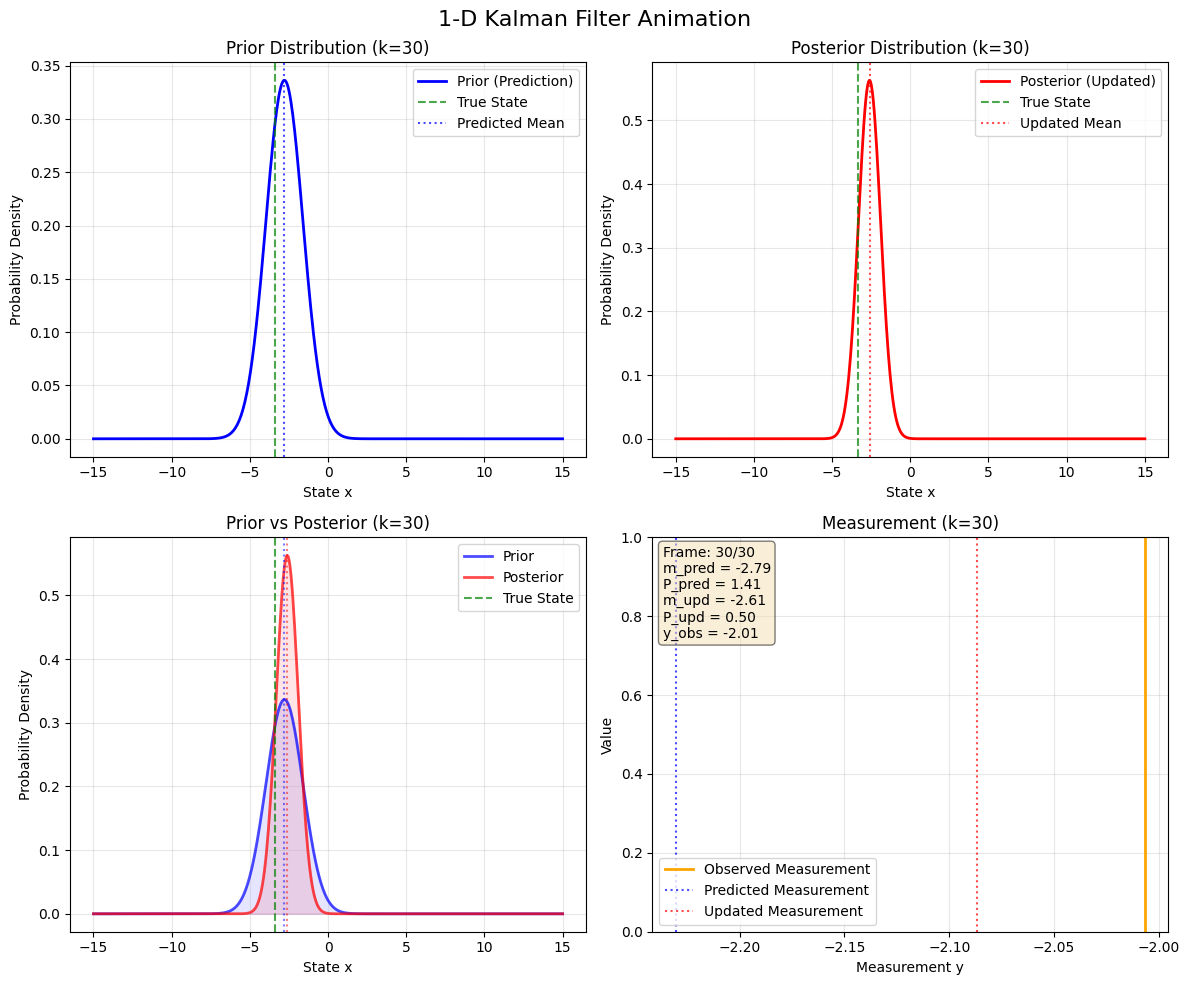

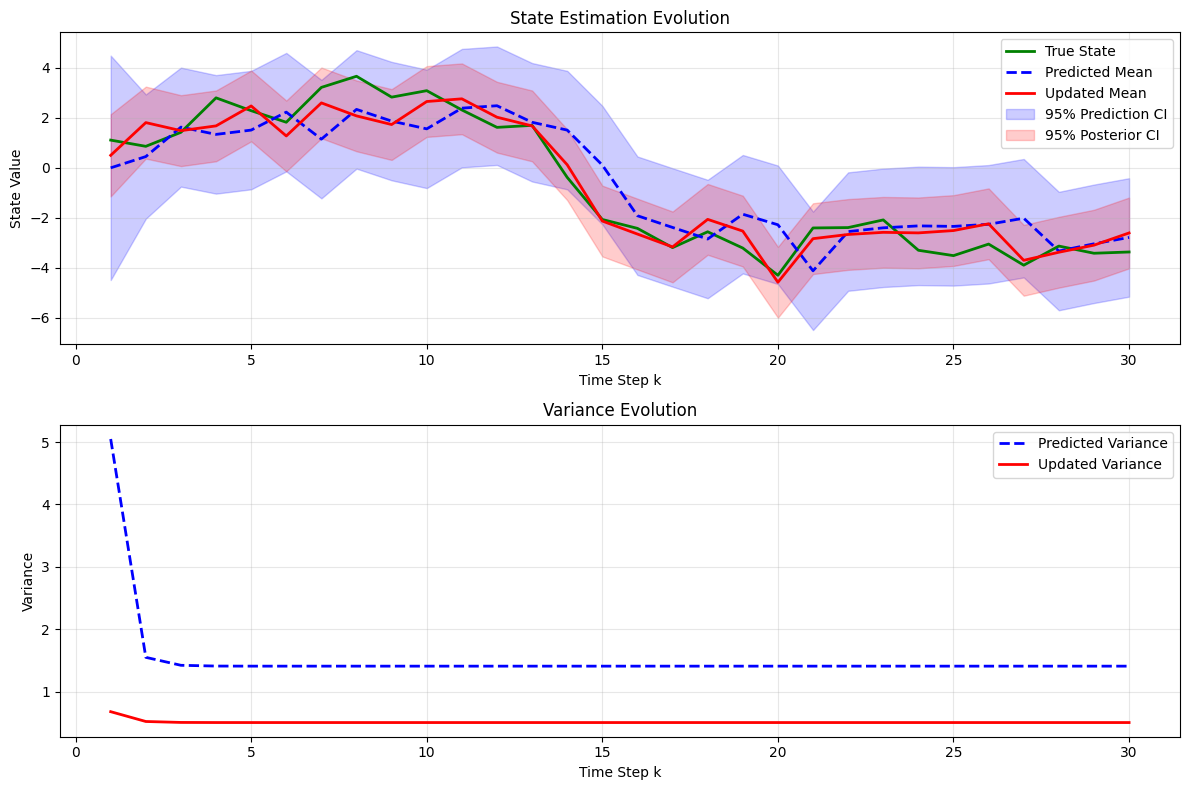

=== Performance Metrics ===
Mean Prediction Error: -0.1297
Mean Update Error: 0.0168
RMSE Prediction: 1.1519
RMSE Update: 0.6347


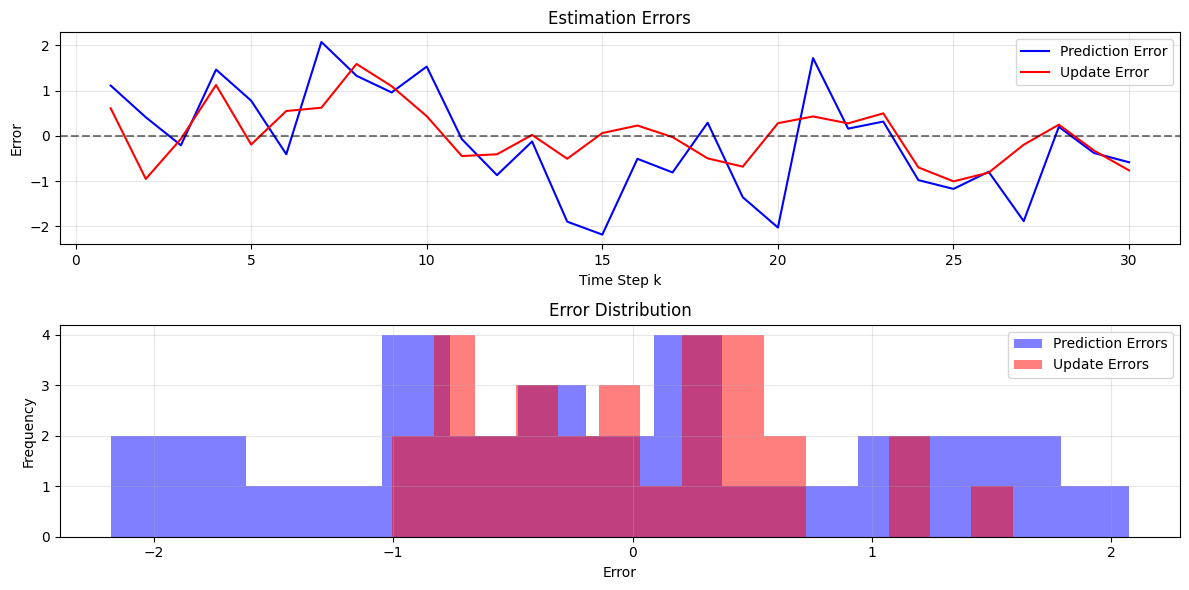

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# Set parameters
a = 0.9        # State transition
q = 1.0        # Process noise variance
h = 0.8        # Measurement matrix
r = 0.5        # Measurement noise variance
m0 = 0.0       # Initial mean
P0 = 5.0       # Initial covariance

# Number of time steps
T = 30

# Generate true states and measurements
np.random.seed(42)
x_true = np.zeros(T)
y_obs = np.zeros(T)

x_true[0] = m0 + np.sqrt(P0) * np.random.randn()

for k in range(1, T):
    x_true[k] = a * x_true[k-1] + np.sqrt(q) * np.random.randn()

for k in range(T):
    y_obs[k] = h * x_true[k] + np.sqrt(r) * np.random.randn()

# Kalman filter storage
m_pred = np.zeros(T)      # Predicted mean
P_pred = np.zeros(T)      # Predicted variance
m_upd = np.zeros(T)       # Updated mean
P_upd = np.zeros(T)       # Updated variance

# Initialize
m_upd[0] = m0
P_upd[0] = P0

for k in range(T):
    # Prediction step
    if k == 0:
        m_pred[k] = a * m0
        P_pred[k] = a**2 * P0 + q
    else:
        m_pred[k] = a * m_upd[k-1]
        P_pred[k] = a**2 * P_upd[k-1] + q

    # Update step
    S_k = h**2 * P_pred[k] + r
    K_k = P_pred[k] * h / S_k
    m_upd[k] = m_pred[k] + K_k * (y_obs[k] - h * m_pred[k])
    P_upd[k] = (1 - K_k * h) * P_pred[k]

# Create animation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('1-D Kalman Filter Animation', fontsize=16)

# Create x-axis for plotting distributions
x_range = np.linspace(-15, 15, 500)

def animate(frame):
    # Clear all subplots
    for ax in axes.flat:
        ax.clear()

    # --- Subplot 1: Prior distribution (prediction) ---
    ax1 = axes[0, 0]
    prior_pdf = norm.pdf(x_range, m_pred[frame], np.sqrt(P_pred[frame]))
    ax1.plot(x_range, prior_pdf, 'b-', linewidth=2, label='Prior (Prediction)')
    ax1.axvline(x_true[frame], color='g', linestyle='--', label='True State', alpha=0.7)
    ax1.axvline(m_pred[frame], color='b', linestyle=':', label='Predicted Mean', alpha=0.7)
    ax1.set_xlabel('State x')
    ax1.set_ylabel('Probability Density')
    ax1.set_title(f'Prior Distribution (k={frame+1})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Subplot 2: Posterior distribution (updated) ---
    ax2 = axes[0, 1]
    posterior_pdf = norm.pdf(x_range, m_upd[frame], np.sqrt(P_upd[frame]))
    ax2.plot(x_range, posterior_pdf, 'r-', linewidth=2, label='Posterior (Updated)')
    ax2.axvline(x_true[frame], color='g', linestyle='--', label='True State', alpha=0.7)
    ax2.axvline(m_upd[frame], color='r', linestyle=':', label='Updated Mean', alpha=0.7)
    ax2.set_xlabel('State x')
    ax2.set_ylabel('Probability Density')
    ax2.set_title(f'Posterior Distribution (k={frame+1})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # --- Subplot 3: Prior vs Posterior ---
    ax3 = axes[1, 0]
    ax3.plot(x_range, prior_pdf, 'b-', linewidth=2, label='Prior', alpha=0.7)
    ax3.plot(x_range, posterior_pdf, 'r-', linewidth=2, label='Posterior', alpha=0.7)
    ax3.axvline(x_true[frame], color='g', linestyle='--', label='True State', alpha=0.7)
    ax3.axvline(m_pred[frame], color='b', linestyle=':', alpha=0.5)
    ax3.axvline(m_upd[frame], color='r', linestyle=':', alpha=0.5)
    ax3.fill_between(x_range, 0, prior_pdf, color='blue', alpha=0.1)
    ax3.fill_between(x_range, 0, posterior_pdf, color='red', alpha=0.1)
    ax3.set_xlabel('State x')
    ax3.set_ylabel('Probability Density')
    ax3.set_title(f'Prior vs Posterior (k={frame+1})')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # --- Subplot 4: Measurement information ---
    ax4 = axes[1, 1]
    # Show measurement
    ax4.axvline(y_obs[frame], color='orange', linewidth=2, label='Observed Measurement')
    ax4.axvline(h * m_pred[frame], color='blue', linestyle=':', label='Predicted Measurement', alpha=0.7)
    ax4.axvline(h * m_upd[frame], color='red', linestyle=':', label='Updated Measurement', alpha=0.7)
    ax4.set_xlabel('Measurement y')
    ax4.set_ylabel('Value')
    ax4.set_title(f'Measurement (k={frame+1})')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # Add text with numerical values
    text_str = f'Frame: {frame+1}/{T}\n'
    text_str += f'm_pred = {m_pred[frame]:.2f}\n'
    text_str += f'P_pred = {P_pred[frame]:.2f}\n'
    text_str += f'm_upd = {m_upd[frame]:.2f}\n'
    text_str += f'P_upd = {P_upd[frame]:.2f}\n'
    text_str += f'y_obs = {y_obs[frame]:.2f}'
    ax4.text(0.02, 0.98, text_str, transform=ax4.transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()

# Create animation
anim = FuncAnimation(fig, animate, frames=T, interval=500, repeat=True)

# Display the animation
HTML(anim.to_html5_video())

# Show the plot
plt.show()


# Plot the evolution of mean and variance over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

time_steps = np.arange(1, T+1)

# Mean evolution
ax1.plot(time_steps, x_true, 'g-', linewidth=2, label='True State')
ax1.plot(time_steps, m_pred, 'b--', linewidth=2, label='Predicted Mean')
ax1.plot(time_steps, m_upd, 'r-', linewidth=2, label='Updated Mean')
ax1.fill_between(time_steps, m_pred - 2*np.sqrt(P_pred), m_pred + 2*np.sqrt(P_pred),
                  color='blue', alpha=0.2, label='95% Prediction CI')
ax1.fill_between(time_steps, m_upd - 2*np.sqrt(P_upd), m_upd + 2*np.sqrt(P_upd),
                  color='red', alpha=0.2, label='95% Posterior CI')
ax1.set_xlabel('Time Step k')
ax1.set_ylabel('State Value')
ax1.set_title('State Estimation Evolution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Variance evolution
ax2.plot(time_steps, P_pred, 'b--', linewidth=2, label='Predicted Variance')
ax2.plot(time_steps, P_upd, 'r-', linewidth=2, label='Updated Variance')
ax2.set_xlabel('Time Step k')
ax2.set_ylabel('Variance')
ax2.set_title('Variance Evolution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate estimation errors
pred_errors = x_true - m_pred
upd_errors = x_true - m_upd

print("=== Performance Metrics ===")
print(f"Mean Prediction Error: {np.mean(pred_errors):.4f}")
print(f"Mean Update Error: {np.mean(upd_errors):.4f}")
print(f"RMSE Prediction: {np.sqrt(np.mean(pred_errors**2)):.4f}")
print(f"RMSE Update: {np.sqrt(np.mean(upd_errors**2)):.4f}")

# Plot errors
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(time_steps, pred_errors, 'b-', label='Prediction Error')
ax1.plot(time_steps, upd_errors, 'r-', label='Update Error')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time Step k')
ax1.set_ylabel('Error')
ax1.set_title('Estimation Errors')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Error histograms
ax2.hist(pred_errors, bins=15, alpha=0.5, label='Prediction Errors', color='blue')
ax2.hist(upd_errors, bins=15, alpha=0.5, label='Update Errors', color='red')
ax2.set_xlabel('Error')
ax2.set_ylabel('Frequency')
ax2.set_title('Error Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2D Position Estimation with Kalman Filter

## Part A: Analytical Derivation

### State-Space Model

The hidden state at time step k is:
$$x_k = \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}$$

### State Transition Matrix A

For a constant-velocity model, the position update is:
$$p_x(k) = p_x(k-1) + v_x(k-1) \Delta t$$
$$p_y(k) = p_y(k-1) + v_y(k-1) \Delta t$$

The velocity remains constant:
$$v_x(k) = v_x(k-1)$$
$$v_y(k) = v_y(k-1)$$

Therefore:
$$x_k = \begin{bmatrix} p_x(k-1) + v_x(k-1)\Delta t \\ p_y(k-1) + v_y(k-1)\Delta t \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix}$$

Thus:
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

### Measurement Matrix H

The measurement consists only of position components:
$$y_k = \begin{bmatrix} p_x^{\text{meas}}(k) \\ p_y^{\text{meas}}(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}$$

Thus:
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

### Process Noise Matrix G

For a constant-velocity model with acceleration noise, the position noise is integrated twice:
$$\Delta p_x = \frac{1}{2} a_x \Delta t^2$$
$$\Delta p_y = \frac{1}{2} a_y \Delta t^2$$
$$\Delta v_x = a_x \Delta t$$
$$\Delta v_y = a_y \Delta t$$

The process noise affects the state as:
$$w_{k-1} = \begin{bmatrix} a_x \\ a_y \end{bmatrix}$$

Therefore:
$$Gw_{k-1} = \begin{bmatrix} \frac{1}{2} \Delta t^2 & 0 \\ 0 & \frac{1}{2} \Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x \\ a_y \end{bmatrix}$$

Thus:
$$G = \begin{bmatrix} \frac{1}{2} \Delta t^2 & 0 \\ 0 & \frac{1}{2} \Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

---



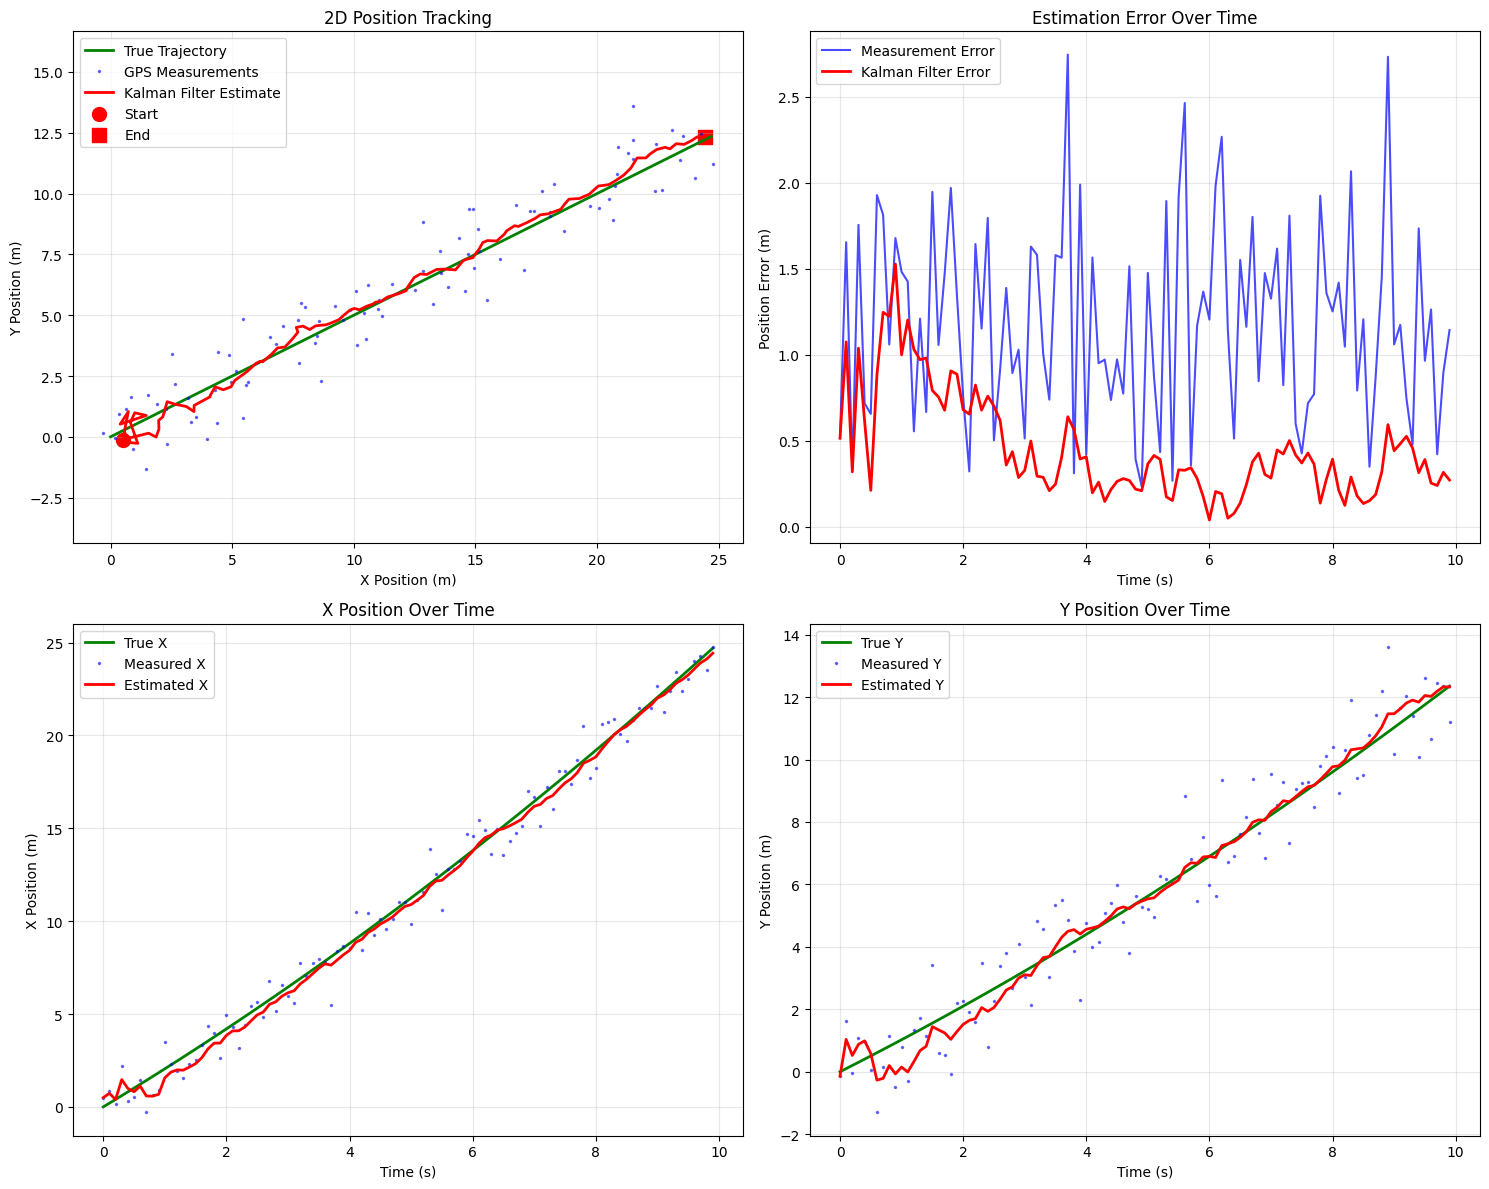

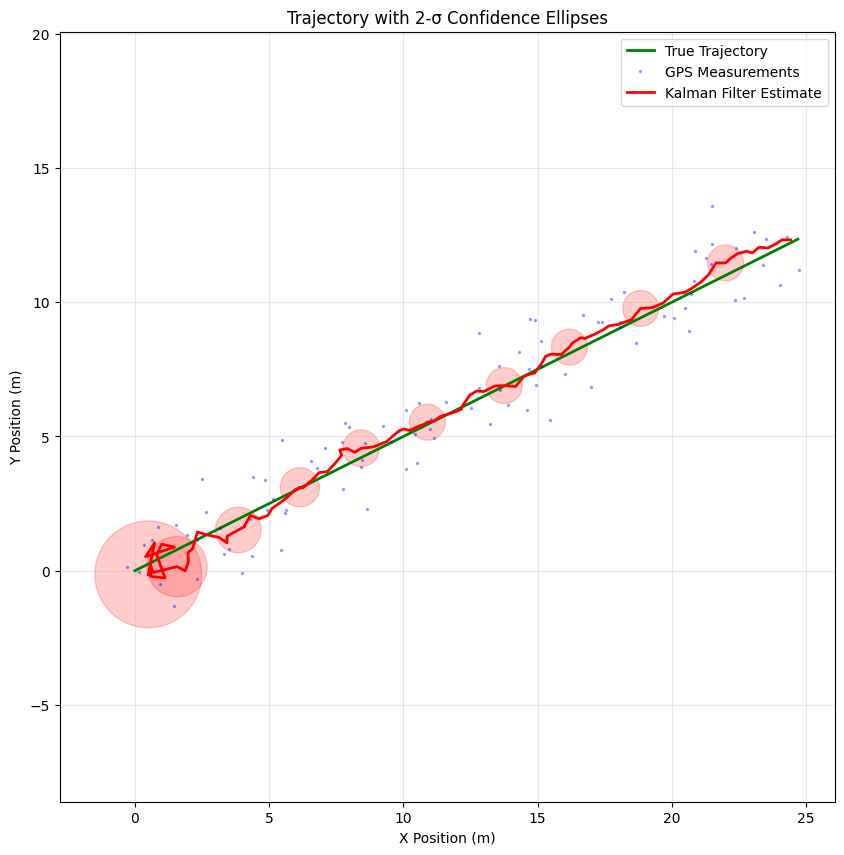

PERFORMANCE METRICS
Initial Position: (0.50, -0.14) m
Final Position: (24.43, 12.33) m
Final Velocity: (2.78, 1.29) m/s
Mean Measurement Error: 1.185 m
Mean Estimation Error: 0.452 m
RMSE Measurement: 1.315 m
RMSE Estimation: 0.543 m
Improvement: 58.7%


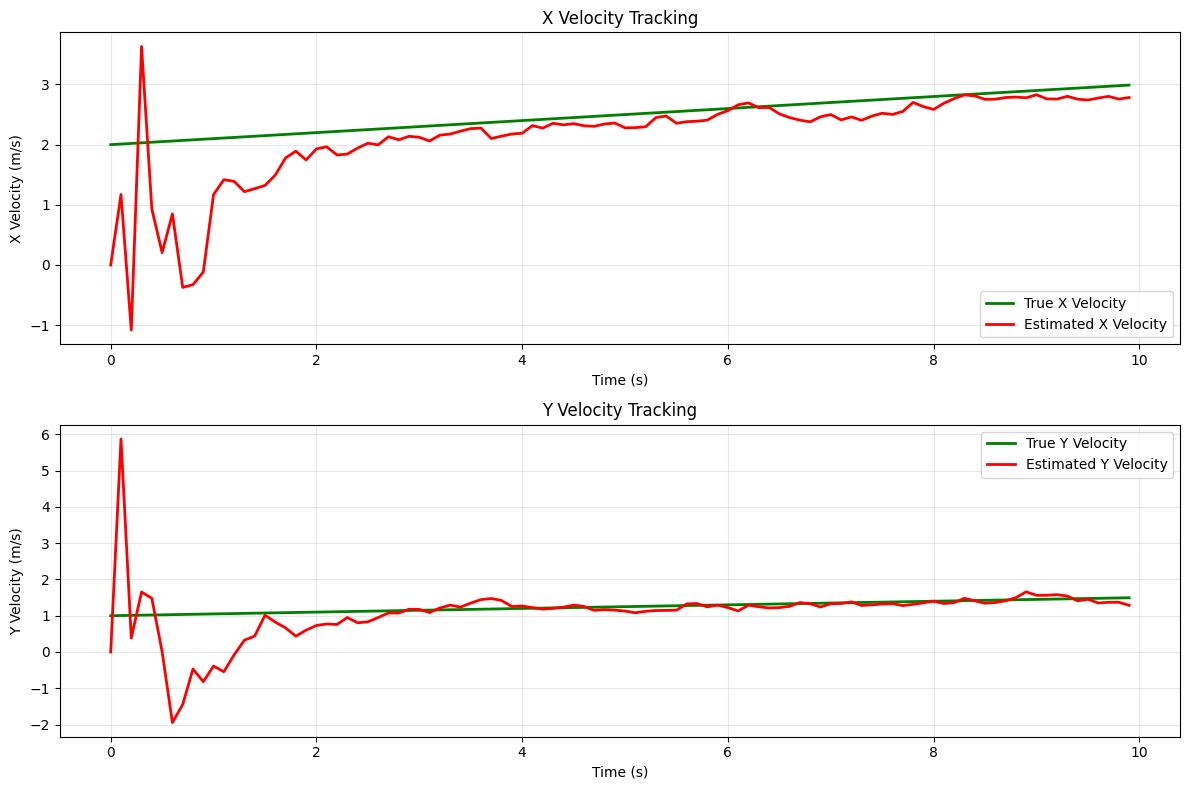

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

class KalmanFilter2D:
    """
    Kalman Filter for 2D position tracking with constant velocity model
    """
    def __init__(self, dt, process_noise_pos, process_noise_vel, measurement_noise):
        """
        Initialize the Kalman Filter

        Parameters:
        dt: time step
        process_noise_pos: position process noise variance
        process_noise_vel: velocity process noise variance
        measurement_noise: measurement noise variance (2x2 matrix)
        """
        self.dt = dt

        # State transition matrix
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])

        # Measurement matrix
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process noise matrix
        self.G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])

        # Process noise covariance
        self.Q = np.array([
            [process_noise_pos, 0],
            [0, process_noise_pos]
        ])

        # Measurement noise covariance
        self.R = measurement_noise

        # Initial state and covariance
        self.x = np.zeros((4, 1))  # [px, py, vx, vy]^T
        self.P = np.eye(4) * 100   # Initial uncertainty

    def predict(self):
        """Prediction step"""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.G @ self.Q @ self.G.T
        return self.x

    def update(self, z):
        """Update step with measurement z"""
        # Innovation
        y = z - self.H @ self.x

        # Innovation covariance
        S = self.H @ self.P @ self.H.T + self.R

        # Kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # Update state
        self.x = self.x + K @ y

        # Update covariance (Joseph form for numerical stability)
        I = np.eye(4)
        self.P = (I - K @ self.H) @ self.P @ (I - K @ self.H).T + K @ self.R @ K.T

        return self.x

    def get_position(self):
        """Get current position estimate"""
        return self.x[0:2].flatten()

    def get_velocity(self):
        """Get current velocity estimate"""
        return self.x[2:4].flatten()

    def get_covariance(self):
        """Get position covariance (2x2)"""
        return self.P[0:2, 0:2]

def generate_gps_data(true_positions, measurement_noise_std):
    """
    Generate noisy GPS measurements from true positions

    Parameters:
    true_positions: array of shape (N, 2) with true positions
    measurement_noise_std: standard deviation of measurement noise

    Returns:
    measurements: array of shape (N, 2) with noisy measurements
    """
    noise = np.random.normal(0, measurement_noise_std, true_positions.shape)
    return true_positions + noise

def confidence_ellipse(mean, cov, ax, n_std=2.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse

    Parameters:
    mean: [x, y] center of ellipse
    cov: 2x2 covariance matrix
    ax: matplotlib axes
    n_std: number of standard deviations for ellipse
    """
    if cov.shape == (2, 2):
        eigvals, eigvecs = np.linalg.eigh(cov)
        order = eigvals.argsort()[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
        width, height = 2 * n_std * np.sqrt(eigvals)
        ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                         facecolor=facecolor, **kwargs)
        ax.add_patch(ellipse)
        return ellipse

# Generate synthetic trajectory
np.random.seed(42)
dt = 0.1  # Time step (seconds)
T = 100   # Number of time steps
total_time = T * dt

# True trajectory parameters
initial_position = np.array([0, 0])
initial_velocity = np.array([2, 1])  # 2 m/s in x, 1 m/s in y
acceleration = np.array([0.1, 0.05])  # Slight acceleration

# Generate true positions (with acceleration)
true_positions = np.zeros((T, 2))
true_velocities = np.zeros((T, 2))

for k in range(T):
    if k == 0:
        true_positions[k] = initial_position
        true_velocities[k] = initial_velocity
    else:
        # Constant acceleration model
        true_velocities[k] = true_velocities[k-1] + acceleration * dt
        true_positions[k] = true_positions[k-1] + true_velocities[k-1] * dt + 0.5 * acceleration * dt**2

# Generate noisy GPS measurements
measurement_noise_std = 1.0  # meters
measurements = generate_gps_data(true_positions, measurement_noise_std)

# Define noise parameters for Kalman Filter
process_noise_pos = 0.5  # Position process noise
process_noise_vel = 0.1  # Velocity process noise
measurement_noise = np.array([[measurement_noise_std**2, 0],
                              [0, measurement_noise_std**2]])

# Initialize Kalman Filter
kf = KalmanFilter2D(dt, process_noise_pos, process_noise_vel, measurement_noise)

# Initialize with first measurement
kf.x = np.array([[measurements[0, 0]], [measurements[0, 1]], [0], [0]])
kf.P = np.eye(4) * 100

# Lists to store results
estimated_positions = []
estimated_velocities = []
position_covariances = []
filtered_measurements = []

# Run Kalman Filter
for k in range(T):
    # Prediction
    kf.predict()

    # Update with measurement
    z = np.array([[measurements[k, 0]], [measurements[k, 1]]])
    kf.update(z)

    # Store results
    estimated_positions.append(kf.get_position())
    estimated_velocities.append(kf.get_velocity())
    position_covariances.append(kf.get_covariance())
    filtered_measurements.append(z.flatten())

estimated_positions = np.array(estimated_positions)
estimated_velocities = np.array(estimated_velocities)

# Plotting results
fig = plt.figure(figsize=(15, 12))

# Plot 1: Trajectory
ax1 = plt.subplot(2, 2, 1)
ax1.plot(true_positions[:, 0], true_positions[:, 1], 'g-', linewidth=2, label='True Trajectory')
ax1.plot(measurements[:, 0], measurements[:, 1], 'b.', alpha=0.5, markersize=3, label='GPS Measurements')
ax1.plot(estimated_positions[:, 0], estimated_positions[:, 1], 'r-', linewidth=2, label='Kalman Filter Estimate')
ax1.scatter(estimated_positions[0, 0], estimated_positions[0, 1], color='red', s=100, marker='o', label='Start')
ax1.scatter(estimated_positions[-1, 0], estimated_positions[-1, 1], color='red', s=100, marker='s', label='End')
ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('2D Position Tracking')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Plot 2: Position error over time
ax2 = plt.subplot(2, 2, 2)
error_meas = np.sqrt(np.sum((true_positions - measurements)**2, axis=1))
error_est = np.sqrt(np.sum((true_positions - estimated_positions)**2, axis=1))
time = np.arange(T) * dt
ax2.plot(time, error_meas, 'b-', label='Measurement Error', alpha=0.7)
ax2.plot(time, error_est, 'r-', label='Kalman Filter Error', linewidth=2)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position Error (m)')
ax2.set_title('Estimation Error Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Position components
ax3 = plt.subplot(2, 2, 3)
ax3.plot(time, true_positions[:, 0], 'g-', label='True X', linewidth=2)
ax3.plot(time, measurements[:, 0], 'b.', alpha=0.5, markersize=3, label='Measured X')
ax3.plot(time, estimated_positions[:, 0], 'r-', label='Estimated X', linewidth=2)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('X Position (m)')
ax3.set_title('X Position Over Time')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(2, 2, 4)
ax4.plot(time, true_positions[:, 1], 'g-', label='True Y', linewidth=2)
ax4.plot(time, measurements[:, 1], 'b.', alpha=0.5, markersize=3, label='Measured Y')
ax4.plot(time, estimated_positions[:, 1], 'r-', label='Estimated Y', linewidth=2)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Y Position (m)')
ax4.set_title('Y Position Over Time')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot with confidence ellipses at selected time steps
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(true_positions[:, 0], true_positions[:, 1], 'g-', linewidth=2, label='True Trajectory')
ax.plot(measurements[:, 0], measurements[:, 1], 'b.', alpha=0.3, markersize=3, label='GPS Measurements')
ax.plot(estimated_positions[:, 0], estimated_positions[:, 1], 'r-', linewidth=2, label='Kalman Filter Estimate')

# Plot confidence ellipses at regular intervals
step_size = 10
for i in range(0, T, step_size):
    pos = estimated_positions[i]
    cov = position_covariances[i]
    if np.linalg.det(cov) > 1e-10:  # Check if covariance is valid
        confidence_ellipse(pos, cov, ax, n_std=2, facecolor='red', alpha=0.2, edgecolor='red')

ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Trajectory with 2-σ Confidence Ellipses')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.show()

# Performance metrics
print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
print(f"Initial Position: ({estimated_positions[0, 0]:.2f}, {estimated_positions[0, 1]:.2f}) m")
print(f"Final Position: ({estimated_positions[-1, 0]:.2f}, {estimated_positions[-1, 1]:.2f}) m")
print(f"Final Velocity: ({estimated_velocities[-1, 0]:.2f}, {estimated_velocities[-1, 1]:.2f}) m/s")
print(f"Mean Measurement Error: {np.mean(error_meas):.3f} m")
print(f"Mean Estimation Error: {np.mean(error_est):.3f} m")
print(f"RMSE Measurement: {np.sqrt(np.mean(error_meas**2)):.3f} m")
print(f"RMSE Estimation: {np.sqrt(np.mean(error_est**2)):.3f} m")
print(f"Improvement: {(1 - np.sqrt(np.mean(error_est**2))/np.sqrt(np.mean(error_meas**2)))*100:.1f}%")

# Plot velocity estimates
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(time, true_velocities[:, 0], 'g-', label='True X Velocity', linewidth=2)
ax1.plot(time, estimated_velocities[:, 0], 'r-', label='Estimated X Velocity', linewidth=2)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('X Velocity (m/s)')
ax1.set_title('X Velocity Tracking')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(time, true_velocities[:, 1], 'g-', label='True Y Velocity', linewidth=2)
ax2.plot(time, estimated_velocities[:, 1], 'r-', label='Estimated Y Velocity', linewidth=2)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Y Velocity (m/s)')
ax2.set_title('Y Velocity Tracking')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()